# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, obligatorio) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier` y `evaluate_classifier` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1: Agustín Accurso
- Alumno 2: Lautaro Cena

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [ ]:
import os
import sys
import subprocess
from pathlib import Path


REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"
REPO_BRANCH = "desarrollo"

IN_COLAB = "google.colab" in sys.modules


def find_project_root(start_path: Path) -> Path | None:
    """
    Busca la raíz del repositorio comprobando que existan
    las carpetas src y scripts.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate

    return None


project_root = find_project_root(Path.cwd())


if project_root is None and IN_COLAB:
    colab_project_path = Path("/content/proyecto")

    if not colab_project_path.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "-b",
                REPO_BRANCH,
                REPO_URL,
                str(colab_project_path),
            ],
            check=True,
        )
    else:
        print(
            "El directorio del proyecto ya existe en Colab; "
            "se reutiliza."
        )

    project_root = find_project_root(colab_project_path)


if project_root is None:
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. "
        "Abrí la notebook desde la carpeta del proyecto o "
        "ejecutala en Google Colab."
    )


ROOT = project_root
SRC = ROOT / "src"

os.chdir(ROOT)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


print(f"Entorno: {'Google Colab' if IN_COLAB else 'local'}")
print(f"Raíz del proyecto: {ROOT}")

c:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\proyecto


fatal: destination path 'proyecto' already exists and is not an empty directory.


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations onnxruntime

In [ ]:
from collections import Counter

# ------------------------------------------------------------
# Configuración mediante variables de entorno
# ------------------------------------------------------------

# La Etapa 2 no utiliza la base vectorial.
# Se define mediante variable de entorno antes de importar settings.
os.environ.setdefault("USE_PGVECTOR", "false")

# Se utiliza una ruta absoluta para que funcione tanto en local
# como en Google Colab.
os.environ.setdefault(
    "DATASET_PATH",
    str(ROOT / "data" / "dataset"),
)

# Cargar configuración externa cuando exista.
from dotenv import load_dotenv

env_candidates = [
    SRC / ".env",
    ROOT / ".env",
    ROOT / ".env.local",
]

loaded_env = None

for env_path in env_candidates:
    if env_path.is_file():
        load_dotenv(env_path, override=False)
        loaded_env = env_path
        break


# ------------------------------------------------------------
# Imports utilizados por la notebook
# ------------------------------------------------------------

import requests
import gdown
import zipfile
import random
import time
import re
import cv2
import shutil

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)

from lib.services.classifier_service import (
    IMAGENET_MEAN,
    IMAGENET_STD,
)

from lib.config import settings
from lib.bootstrap import build_classifier


print(f"Configuración externa cargada: {loaded_env}")
print(f"Dataset configurado: {settings.dataset_path}")
print(
    f"Existe la carpeta del dataset: "
    f"{settings.dataset_path.exists()}"
)
print(
    f"Existe train: "
    f"{(settings.dataset_path / 'train').exists()}"
)

ROOT: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app
Dataset configurado: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset
Existe la carpeta del dataset: True
Existe train: True


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determinismo en operaciones de cuDNN (a costa de algo de velocidad).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fijada en {SEED} para numpy, random, torch y CUDA.")

Seed fijada en 42 para numpy, random, torch y CUDA.


## 4. Descargar el dataset

In [6]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\dogs.csv
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\test
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\train
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\valid
Dataset disponible en C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset


"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## 5. Analisis del dataset


### Definir conjuntos de entrenamiento, validacion y prueba, y analizar la distribucion de clases, documentando cantidad de imagenes por raza.

In [7]:
result = subprocess.run(["python", "scripts/download_dataset.py"], cwd=ROOT, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print("dataset existe ahora:", (settings.dataset_path / "train").is_dir())

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\dogs.csv
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\test
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\train
Ya existe, se omite: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset\valid
Dataset disponible en C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset


dataset existe ahora: True


In [8]:
print(settings.dataset_path)
print(settings.dataset_path.exists())
print(list(settings.dataset_path.parent.iterdir()) if settings.dataset_path.parent.exists() else "ni el padre existe")

C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\dataset
True
[WindowsPath('C:/Users/IKON/Desktop/tp2-CV/tuia-dog-recognition-app/data/dataset'), WindowsPath('C:/Users/IKON/Desktop/tp2-CV/tuia-dog-recognition-app/data/embeddings.json'), WindowsPath('C:/Users/IKON/Desktop/tp2-CV/tuia-dog-recognition-app/data/external_eval')]


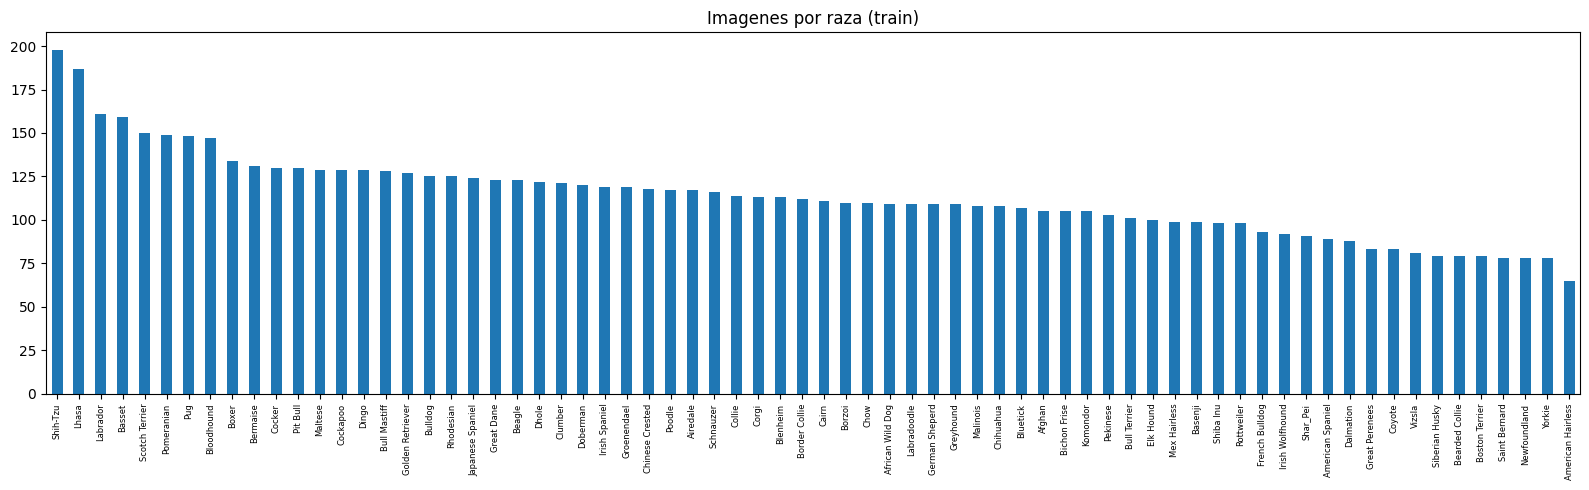

Total razas: 70
Min/Max imagenes por raza: 65 / 198
Promedio de imagenes por raza: 113.5
Desvio estandar: 24.7
Razas con menos de 100 imagenes: 19 de 70
train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


In [9]:
breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
df_counts.plot(kind="bar", ax=ax, title="Imagenes por raza (train)")
ax.set_xticklabels(df_counts.index, rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("output/class_distribution_etapa2.png", dpi=100)
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")
print(f"Promedio de imagenes por raza: {df_counts.mean():.1f}")
print(f"Desvio estandar: {df_counts.std():.1f}")
print(f"Razas con menos de 100 imagenes: {(df_counts < 100).sum()} de {len(df_counts)}")

for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

### Conjunto de validación externa:

In [10]:
EXTERNAL_SET_PATH = settings.dataset_path.parent / "external_eval"

shutil.rmtree(EXTERNAL_SET_PATH, ignore_errors=True)
EXTERNAL_SET_PATH.mkdir(parents=True, exist_ok=True)

file_id = '1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS'
url = f'https://drive.google.com/uc?id={file_id}'
zip_path = EXTERNAL_SET_PATH / 'temp_dataset.zip'

gdown.download(url, str(zip_path), quiet=False)
print("zip size:", zip_path.stat().st_size)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(EXTERNAL_SET_PATH)

os.remove(zip_path)

print("Contenido de EXTERNAL_SET_PATH:")
for p in sorted(EXTERNAL_SET_PATH.iterdir()):
    print(" ", p.name, "(dir)" if p.is_dir() else "(file)")

n_external = sum(1 for p in EXTERNAL_SET_PATH.rglob("*") if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
n_external_breeds = sum(1 for p in EXTERNAL_SET_PATH.iterdir() if p.is_dir())
print(f"Conjunto externo: {n_external} imágenes, {n_external_breeds} razas")

Downloading...
From: https://drive.google.com/uc?id=1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS
To: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app\data\external_eval\temp_dataset.zip
100%|██████████| 13.2M/13.2M [00:08<00:00, 1.47MB/s]

zip size: 13184459
Contenido de EXTERNAL_SET_PATH:
  Basset (dir)
  Border Collie (dir)
  Doberman (dir)
  Golden Retriever (dir)
  Poodle (dir)
Conjunto externo: 26 imágenes, 5 razas


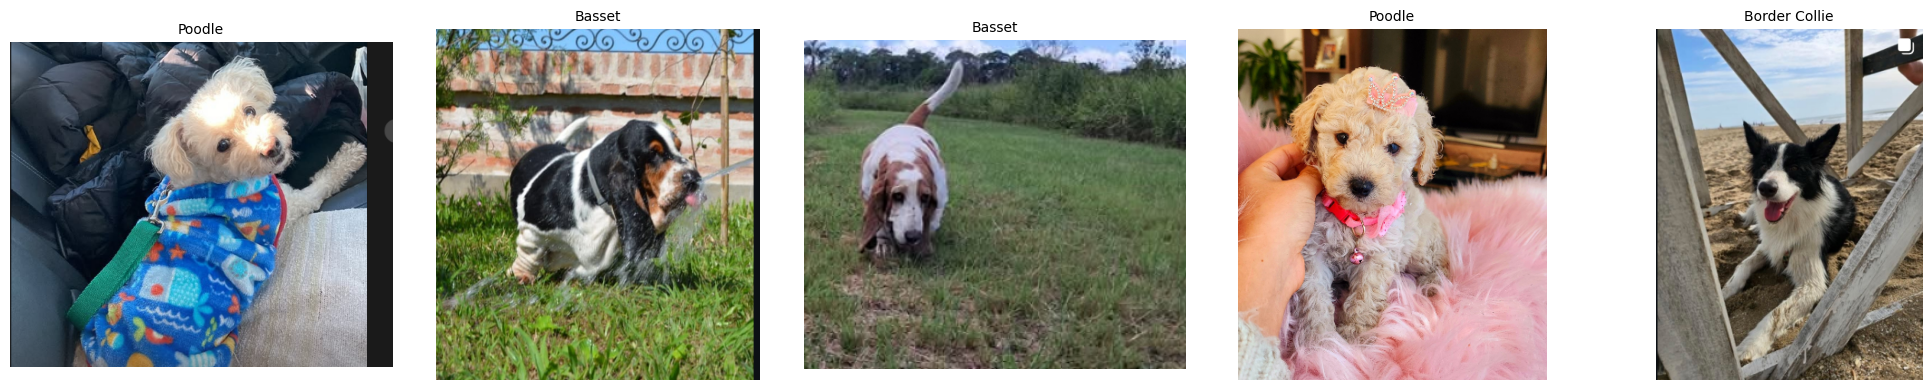

In [11]:
todas_las_imgs = list(EXTERNAL_SET_PATH.rglob("*.png")) + list(EXTERNAL_SET_PATH.rglob("*.jpg"))
muestra = random.sample(todas_las_imgs, min(5, len(todas_las_imgs)))

fig, axes = plt.subplots(1, len(muestra), figsize=(4 * len(muestra), 4))
if len(muestra) == 1:
    axes = [axes]
for ax, img_path in zip(axes, muestra):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(img_path.parent.name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("output/external_eval_sample.png", dpi=100)
plt.show()

### Conclusiones del análisis exploratorio — Etapa 2

El conjunto de entrenamiento contiene **7.946 imágenes distribuidas en 70
razas**, con entre **65 y 198 imágenes por clase**. El promedio es de
aproximadamente **113,5 imágenes por raza**, y **19 de las 70 clases**
poseen menos de 100 ejemplos. Por lo tanto, existe un desbalance moderado que
debe considerarse al interpretar las métricas por clase.

En la Etapa 2, este desbalance puede influir directamente en el aprendizaje,
porque los modelos actualizan sus parámetros a partir de la distribución de
`train`. Las clases con menos ejemplos aportan menos actualizaciones durante
el entrenamiento y podrían presentar menor recall o mayor variabilidad en sus
resultados. Esta posibilidad se comprobará posteriormente mediante las métricas
por clase y las matrices de confusión, sin asumir de antemano que todas las
clases minoritarias necesariamente tendrán peor desempeño.

El desbalance también puede afectar la Etapa 1, aunque de una manera diferente.
El extractor preentrenado no se ajusta con este dataset, por lo que la
distribución de clases no modifica sus pesos. Sin embargo, las clases con mayor
cantidad de imágenes tienen una representación más numerosa en la base
vectorial y, por lo tanto, pueden aparecer con mayor frecuencia entre los
vecinos recuperados y participar más veces en la predicción por similitud.

Los conjuntos `valid` y `test` se mantienen separados de `train`, y además se
construyó un conjunto externo de **26 imágenes pertenecientes a 5 razas**.
Este conjunto externo se utilizará como evaluación complementaria de
generalización, pero no reemplaza al conjunto de prueba principal porque no
representa las 70 clases del problema.

## 6. Preprocesamiento

### Filtrado de imagenes de baja calidad
**Criterio**: descartar imagenes corruptas (no abren con PIL) o con resolucion por debajo de un minimo razonable para el resize a self.image_size.

In [12]:
MIN_RESOLUTION = 64  # px por lado, umbral minimo aceptado

def filtrar_imagenes_baja_calidad(dataset_path, splits=("train", "valid", "test"), min_resolution=MIN_RESOLUTION):
    """
    Recorre cada split y elimina imagenes corruptas o de resolucion
    insuficiente. Devuelve un detalle de lo eliminado para documentar
    en el informe.
    """
    eliminadas = []
    for split in splits:
        split_path = dataset_path / split
        for img_path in split_path.rglob("*.jpg"):
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    w, h = img.size
                    if w < min_resolution or h < min_resolution:
                        eliminadas.append((split, img_path.name, f"resolucion {w}x{h}"))
                        img_path.unlink()
            except Exception as e:
                eliminadas.append((split, img_path.name, f"corrupta: {e}"))
                img_path.unlink(missing_ok=True)
    return eliminadas

eliminadas = filtrar_imagenes_baja_calidad(settings.dataset_path)
print(f"Imagenes eliminadas por baja calidad: {len(eliminadas)}")
for split, nombre, motivo in eliminadas[:20]:
    print(f"  [{split}] {nombre}: {motivo}")

Imagenes eliminadas por baja calidad: 0


Se aplico un filtro que descarta imagenes corruptas (que no pueden abrirse
o verificarse con PIL) y aquellas con resolucion menor a 64px en algun lado,
umbral elegido para evitar que el resize a `image_size` distorsione
excesivamente imagenes muy pequeñas.

Resultado: 0 imagenes eliminadas sobre el total del dataset. Esto es
consistente con que el 70 Dog Breeds Dataset de Kaggle ya viene
relativamente curado (a diferencia de un dataset armado por scraping
directo), por lo que no se encontraron archivos corruptos ni de
resolucion insuficiente en ninguno de los tres splits.

### Resize, normalizacion y data augmentation

- **Resize:** todas las imagenes se redimensionan a `image_size x image_size`
  (configurable via `.env`), tamaño compatible con la entrada esperada por
  ResNet18 preentrenado en ImageNet.
- **Normalizacion:** se usan media y desvio estandar de ImageNet
  (`IMAGENET_MEAN`, `IMAGENET_STD`), ya que el Modelo A reutiliza pesos
  preentrenados en ese dataset; mantener la misma normalizacion con la que
  el backbone fue originalmente entrenado evita un corrimiento de
  distribucion que degradaria el fine-tuning. Se aplica la misma
  normalizacion al Modelo B (CNN propia, sin pesos preentrenados) por
  consistencia y simplicidad, aunque en ese caso no es estrictamente
  necesaria.
- **Data Augmentation (solo en train):**
  - Horizontal Flip (p=0.5): las razas de perro no tienen una orientacion
    canonica relevante, por lo que espejar horizontalmente es una
    transformacion valida que no distorsiona la clase.
  - Rotacion (±15°): simula variacion natural en el angulo de toma de
    la foto, sin rotar tanto como para deformar la pose del animal.
  - Variaciones de brillo y contraste (ColorJitter, ±0.2): compensa
    diferencias de iluminacion entre fotos (interior/exterior, distintas
    camaras).

No se implementaron blur ni inyeccion de ruido como augmentation. Se evaluo
que, para un problema de clasificacion de razas (donde el detalle textural
del pelaje es informativo), introducir blur o ruido sintetico podria
degradar features relevantes sin un beneficio claro de generalizacion
adicional al ya aportado por flip, rotacion y color jitter. Se prioriza
augmentation que simula variabilidad real de captura (angulo, iluminacion)
sobre degradacion sintetica de la imagen.

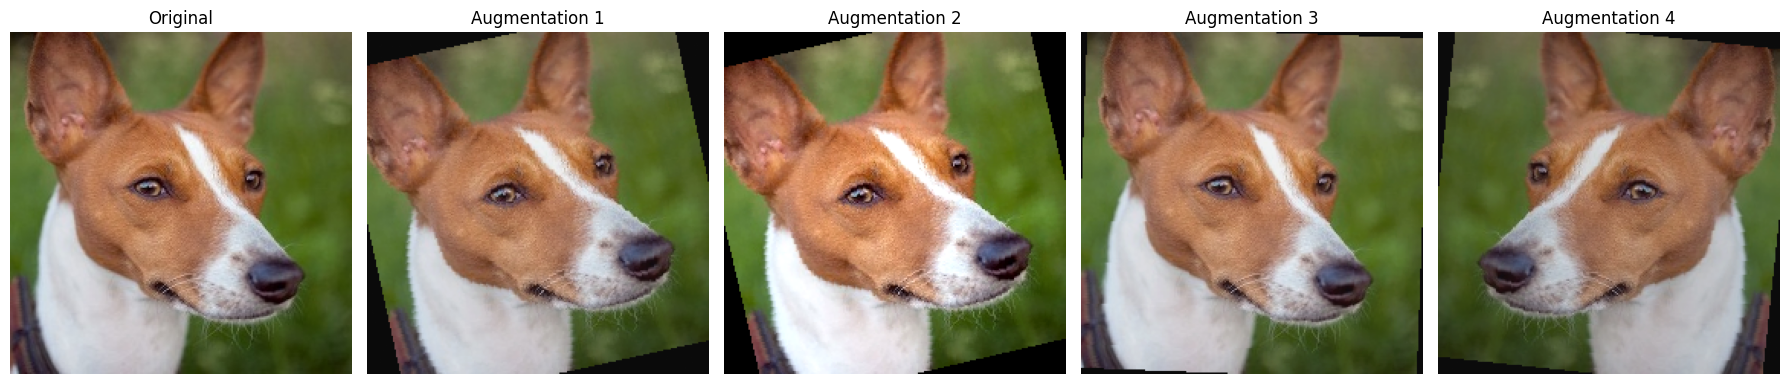

In [13]:
classifier_preview = build_classifier(settings)
train_tf = classifier_preview._build_transforms(train=True)
valid_tf = classifier_preview._build_transforms(train=False)

# Tomamos una imagen de ejemplo
sample_breed = breeds[5]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.*"))

img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
for i in range(1, 5):
    augmented = train_tf(img)
    # des-normalizar para visualizar
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) if 'IMAGENET_MEAN' in dir() else torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1) if 'IMAGENET_STD' in dir() else torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    denorm = (augmented * std + mean).clamp(0,1).permute(1,2,0).numpy()
    axes[i].imshow(denorm)
    axes[i].set_title(f"Augmentation {i}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("output/augmentation_examples.png", dpi=100)
plt.show()

### Normalizacion de nombres de carpetas

Se detecto una inconsistencia en los nombres de carpetas de razas entre
splits (ej. espacios dobles en `valid` vs `train`), que `ImageFolder`
trata como clases distintas. Se normalizan los espacios antes de
entrenar para evitar este desajuste.

In [14]:
def normalizar_nombres_carpetas(dataset_path, splits=("train", "valid", "test")):
    """
    Normaliza espacios múltiples a uno solo en los nombres de carpetas de
    cada raza, en los tres splits. Necesario porque el dataset de Kaggle
    tiene inconsistencias (ej. 'American Spaniel' vs 'American  Spaniel').
    """
    renombradas = []
    for split in splits:
        split_path = dataset_path / split
        for breed_dir in sorted(split_path.iterdir()):
            if not breed_dir.is_dir():
                continue
            nombre_normalizado = re.sub(r"\s+", " ", breed_dir.name).strip()
            if nombre_normalizado != breed_dir.name:
                destino = split_path / nombre_normalizado
                breed_dir.rename(destino)
                renombradas.append((split, breed_dir.name, nombre_normalizado))
    return renombradas

cambios = normalizar_nombres_carpetas(settings.dataset_path)
for split, antes, despues in cambios:
    print(f"[{split}] '{antes}' -> '{despues}'")
print(f"\nTotal carpetas renombradas: {len(cambios)}")

# Verificacion: confirmar que ahora coinciden entre splits
train_classes = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
valid_classes = sorted(p.name for p in (settings.dataset_path / "valid").iterdir() if p.is_dir())
test_classes = sorted(p.name for p in (settings.dataset_path / "test").iterdir() if p.is_dir())

assert train_classes == valid_classes == test_classes, "Todavia hay inconsistencias entre splits"
print("Clases consistentes entre train/valid/test:", len(train_classes))

[valid] 'American  Spaniel' -> 'American Spaniel'

Total carpetas renombradas: 1
Clases consistentes entre train/valid/test: 70


## 7. Modelo A (obligatorio): fine-tuning de ResNet18

**Hiperparametros utilizados:**

| Parametro | Valor | Justificacion |
|---|---|---|
| Batch size | 32 | Balance entre estabilidad del gradiente y memoria disponible en GPU T4 de Colab. |
| Epochs maximas | 15 | Suficiente para converger con early stopping; se evito un numero mayor para no incurrir en tiempo de entrenamiento innecesario. |
| Patience | 4 | Tolerancia de 4 epochs sin mejora en valid_loss antes de detener, evitando overfitting sin cortar prematuramente. |
| LR head (fc) | 1e-3 | Learning rate mas alto para la capa final, que se entrena desde cero. |
| LR backbone (layer4) | 1e-4 | Learning rate mas bajo para las capas preentrenadas que se descongelan, evitando destruir features ya aprendidas en ImageNet (fine-tuning conservador). |
| Step size (scheduler) | 5 | El LR decae cada 5 epochs. |
| Gamma (scheduler) | 0.5 | El LR se reduce a la mitad en cada decay, permitiendo ajuste fino en epochs tardias. |

Arquitectura: solo se descongelan `layer4` y la capa `fc` final de ResNet18;
el resto del backbone permanece congelado, ya que las capas iniciales
capturan features genericas (bordes, texturas) reutilizables sin
reentrenamiento, mientras que `layer4` captura features mas especificas
que conviene adaptar al dominio de razas de perros.

No se realizó búsqueda de hiperparámetros (LR, batch size, etc.) para el
Modelo A; los valores de la tabla fueron elegidos por criterio razonado
(justificado de la tabla) y no ajustados empíricamente mediante
grid search o similar, por motivos de tiempo y costo de cómputo. El
checkpoint guardado corresponde al de menor valid_loss, no al de mayor
valid_acc; se verifica en la sección de Estudio Comparativo si ambos
criterios coinciden en la práctica para este dataset.

In [15]:
classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

c:\Users\IKON\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:lib.services.classifier_service:epoch 1/15 - train_loss=1.3015 train_acc=0.6890 valid_loss=0.2946 valid_acc=0.9214
INFO:lib.services.classifier_service:epoch 2/15 - train_loss=0.4152 train_acc=0.8812 valid_loss=0.2091 valid_acc=0.9429
INFO:lib.services.classifier_service:epoch 3/15 - train_loss=0.2839 train_acc=0.9184 valid_loss=0.1677 valid_acc=0.9414
INFO:lib.services.classifier_service:epoch 4/15 - train_loss=0.1984 train_acc=0.9396 valid_loss=0.1709 valid_acc=0.9414
INFO:lib.services.classifier_service:epoch 5/15 - train_loss=0.1458 train_acc=0.9585 valid_loss=0.2075 valid_acc=0.9343
INFO:lib.services.classifier_service:epoch 6/15 - train_loss=0.0886 train_acc=0.9753 valid_loss=0.1326 valid_acc=0.9586
INFO:lib.services.classi

In [16]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9614285714285714,
 'precision': 0.9627494727494726,
 'recall': 0.9614285714285716,
 'specificity': 0.9994409937888199,
 'f1': 0.9601237565964601}

In [17]:
checkpoint = torch.load(classifier.active_checkpoint, map_location="cpu", weights_only=False)
history = checkpoint["history"]

### Curvas de entrenamiento y matriz de confusion (Modelo A)


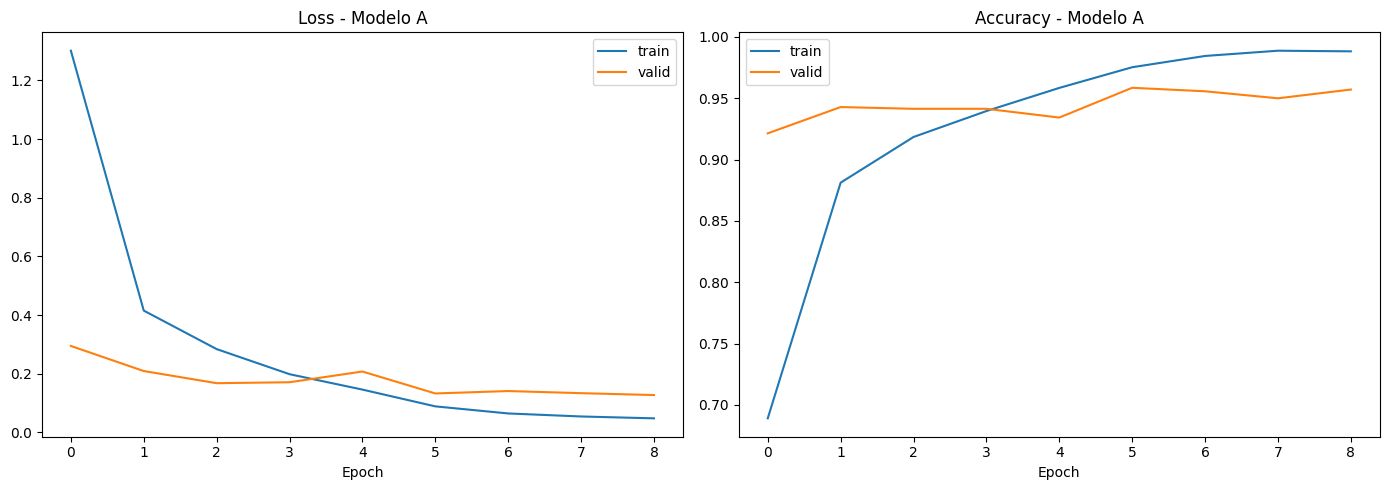

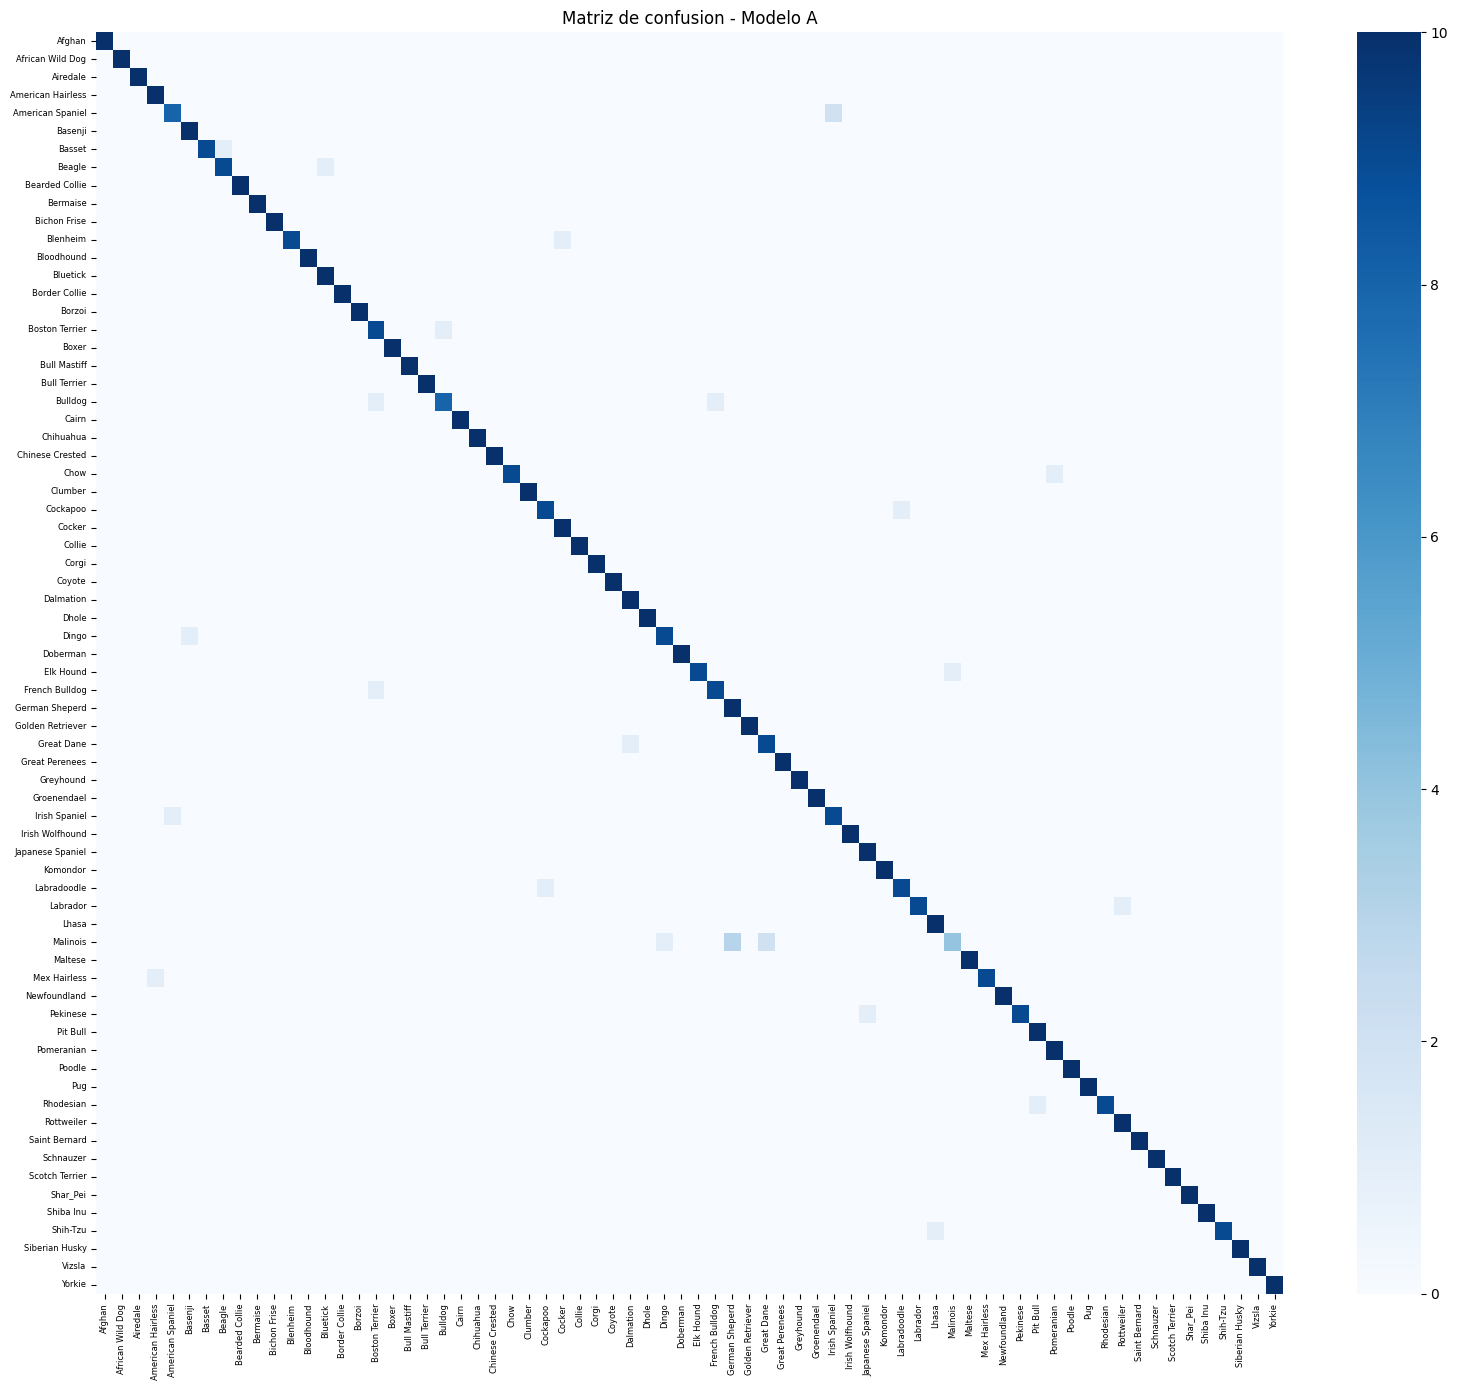

In [18]:
checkpoint_a = torch.load(settings.model_path / settings.resnet18_model_name, map_location="cpu", weights_only=False)
history_a = checkpoint_a["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_a["train_loss"], label="train")
axes[0].plot(history_a["valid_loss"], label="valid")
axes[0].set_title("Loss - Modelo A")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_a["train_acc"], label="train")
axes[1].plot(history_a["valid_acc"], label="valid")
axes[1].set_title("Accuracy - Modelo A")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("output/curves_model_a.png", dpi=100)
plt.show()

# Matriz de confusion sobre test
class_names = checkpoint_a["class_names"]
model_a = classifier._build_resnet18_finetuned(len(class_names))
model_a.load_state_dict(checkpoint_a["model_state_dict"])
model_a.eval()

test_tf = classifier._build_transforms(train=False)
test_ds = datasets.ImageFolder(settings.dataset_path / "test", transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=settings.batch_size, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(classifier.device)
        outputs = model_a(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Matriz de confusion - Modelo A")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("output/confusion_matrix_a.png", dpi=100)
plt.show()

### Análisis Modelo A (ResNet18 Fine-Tuned)
Las curvas muestran convergencia estable con un leve overfitting a partir de la
epoch 4 aprox, con una brecha train-valid pequeña. En la matriz de confusión, las razas con peor desempeño son
Malinois (pastor belga), que suelen confundirse con German Sheperd (pastor alemán),
lo cual es consistente con similitud visual entre razas.

## 8. Modelo B (obligatorio): CNN propia

Arquitectura: CNN convolucional simple de 4 bloques (Conv2d + BatchNorm + ReLU +
MaxPool2d), con AdaptiveAvgPool2d y una capa Dropout antes de la capa final,
entrenada desde cero (sin pesos preentrenados) a diferencia del Modelo A.
Se reutilizan los mismos hiperparametros de entrenamiento (batch size, epochs,
patience, scheduler) que el Modelo A, salvo el learning rate: al no haber
backbone preentrenado que proteger, se usa un unico learning rate
(`LR_HEAD = 1e-3`) sobre todos los parametros del modelo, sin el esquema
diferenciado head/backbone del Modelo A.

No se realizó búsqueda de hiperparámetros específica para el Modelo B.
Se mantiene LR=1e-3 por simplicidad y por ser el mismo orden de magnitud
usado para el head de A, asumiendo que una CNN entrenada desde cero con
pocas capas tolera un LR único sin esquema diferenciado. Igual que en el
Modelo A, una búsqueda de LR (ej. LR finder) queda fuera del alcance de
esta entrega por motivos de tiempo.

In [19]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

c:\Users\IKON\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:lib.services.classifier_service:epoch 1/15 - train_loss=3.9697 train_acc=0.0559 valid_loss=3.7750 valid_acc=0.0757
INFO:lib.services.classifier_service:epoch 2/15 - train_loss=3.6919 train_acc=0.0982 valid_loss=3.5438 valid_acc=0.1143
INFO:lib.services.classifier_service:epoch 3/15 - train_loss=3.5198 train_acc=0.1248 valid_loss=3.3427 valid_acc=0.1500
INFO:lib.services.classifier_service:epoch 4/15 - train_loss=3.3701 train_acc=0.1602 valid_loss=3.1851 valid_acc=0.1657
INFO:lib.services.classifier_service:epoch 5/15 - train_loss=3.2444 train_acc=0.1824 valid_loss=2.9792 valid_acc=0.2243
INFO:lib.services.classifier_service:epoch 6/15 - train_loss=3.0777 train_acc=0.2128 valid_loss=2.8835 valid_acc=0.2457
INFO:lib.services.classi

{'accuracy': 0.38142857142857145,
 'precision': 0.37966442260446287,
 'recall': 0.3814285714285714,
 'specificity': 0.9910351966873707,
 'f1': 0.35260486875002317}

### Curvas de entrenamiento y matriz de confusion (Modelo B)

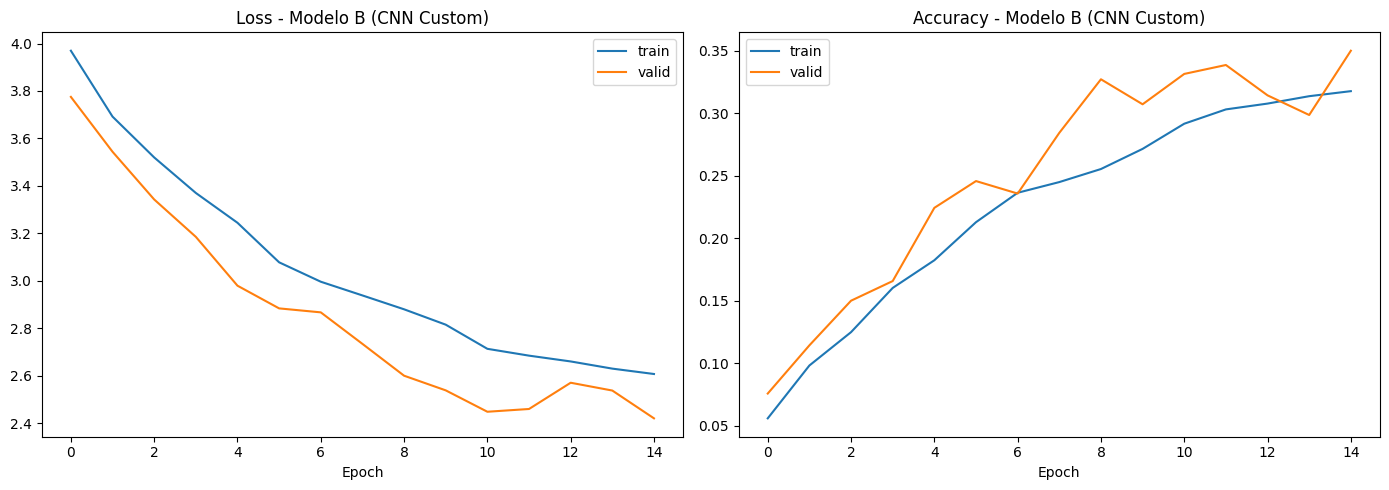

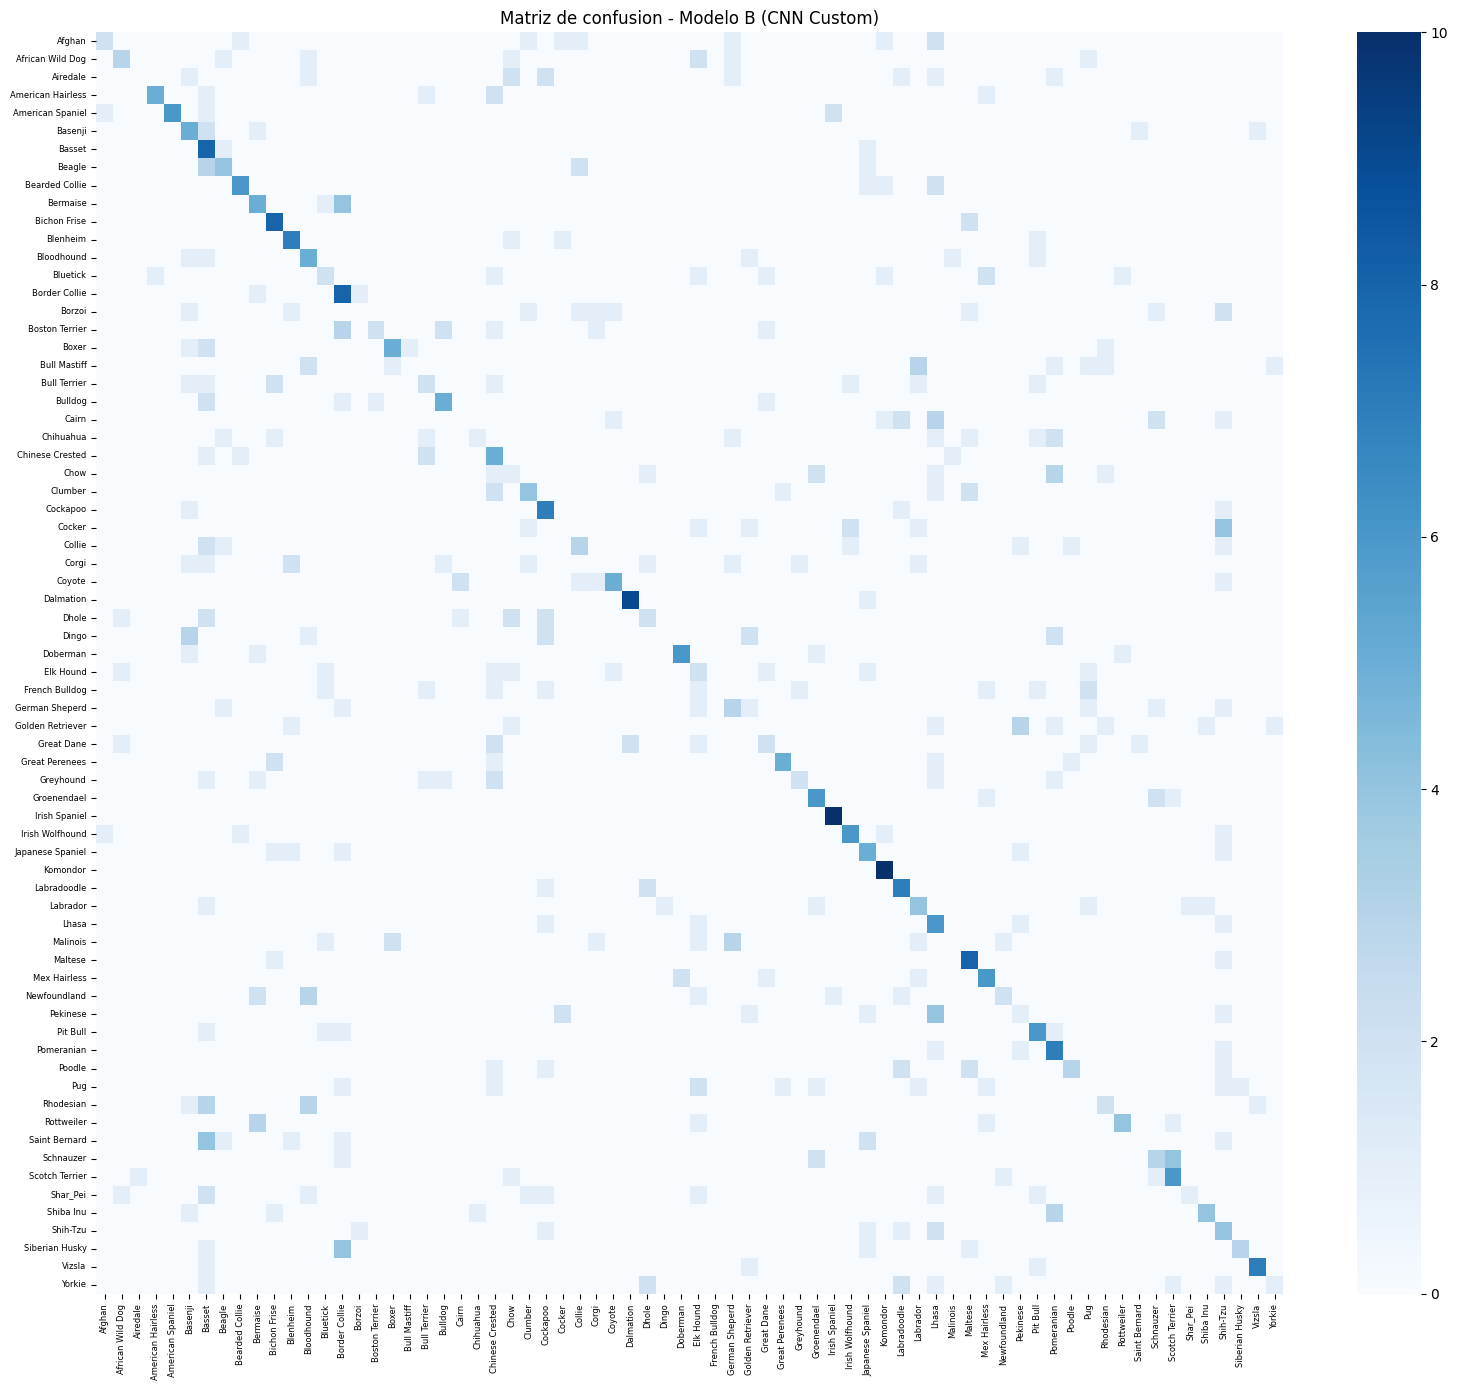

In [20]:
# Curvas de entrenamiento y matriz de confusion (Modelo B)
checkpoint_b = torch.load(classifier.checkpoints["cnn_custom"], map_location="cpu", weights_only=False)
history_b = checkpoint_b["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_b["train_loss"], label="train")
axes[0].plot(history_b["valid_loss"], label="valid")
axes[0].set_title("Loss - Modelo B (CNN Custom)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_b["train_acc"], label="train")
axes[1].plot(history_b["valid_acc"], label="valid")
axes[1].set_title("Accuracy - Modelo B (CNN Custom)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("output/curves_model_b.png", dpi=100)
plt.show()

class_names_b = checkpoint_b["class_names"]
model_b = classifier._build_cnn_custom(len(class_names_b))
model_b.load_state_dict(checkpoint_b["model_state_dict"])
model_b.eval()

test_tf = classifier._build_transforms(train=False)
test_ds_b = datasets.ImageFolder(settings.dataset_path / "test", transform=test_tf)
test_loader_b = DataLoader(test_ds_b, batch_size=settings.batch_size, shuffle=False)

all_preds_b, all_labels_b = [], []
with torch.no_grad():
    for images, labels in test_loader_b:
        images = images.to(classifier.device)
        outputs = model_b(images)
        all_preds_b.extend(outputs.argmax(1).cpu().numpy())
        all_labels_b.extend(labels.numpy())

cm_b = confusion_matrix(all_labels_b, all_preds_b)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_b, xticklabels=class_names_b, yticklabels=class_names_b, cmap="Blues")
plt.title("Matriz de confusion - Modelo B (CNN Custom)")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("output/confusion_matrix_b.png", dpi=100)
plt.show()

In [ ]:
from IPython.display import Markdown, display


# ------------------------------------------------------------
# Resumen de las curvas
# ------------------------------------------------------------

epochs_b = len(history_b["train_loss"])

best_valid_loss_index_b = int(
    np.argmin(history_b["valid_loss"])
)

best_valid_acc_index_b = int(
    np.argmax(history_b["valid_acc"])
)

best_valid_loss_epoch_b = (
    best_valid_loss_index_b + 1
)

best_valid_acc_epoch_b = (
    best_valid_acc_index_b + 1
)

final_train_loss_b = float(
    history_b["train_loss"][-1]
)

final_valid_loss_b = float(
    history_b["valid_loss"][-1]
)

final_train_acc_b = float(
    history_b["train_acc"][-1]
)

final_valid_acc_b = float(
    history_b["valid_acc"][-1]
)


# ------------------------------------------------------------
# Clases con menor recall
# ------------------------------------------------------------

samples_per_class_b = cm_b.sum(axis=1)

recall_per_class_b = np.divide(
    np.diag(cm_b),
    samples_per_class_b,
    out=np.zeros_like(
        samples_per_class_b,
        dtype=float,
    ),
    where=samples_per_class_b != 0,
)

worst_indices_b = np.argsort(
    recall_per_class_b
)[:5]

worst_classes_b = [
    (
        class_names_b[index],
        float(recall_per_class_b[index]),
    )
    for index in worst_indices_b
]


# ------------------------------------------------------------
# Principales confusiones de esas clases
# ------------------------------------------------------------

confusion_lines_b = []

for class_index in worst_indices_b:
    row = cm_b[class_index].copy()
    row[class_index] = 0

    confused_index = int(np.argmax(row))
    confused_amount = int(row[confused_index])

    class_name = class_names_b[class_index]
    class_recall = recall_per_class_b[class_index]

    if confused_amount > 0:
        confusion_lines_b.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; principal confusión con "
            f"**{class_names_b[confused_index]}** "
            f"({confused_amount} imágenes)."
        )
    else:
        confusion_lines_b.append(
            f"- **{class_name}**: recall "
            f"{class_recall:.2f}; sin una confusión "
            "predominante única."
        )


# ------------------------------------------------------------
# Interpretación prudente de la convergencia
# ------------------------------------------------------------

best_loss_is_last_epoch_b = (
    best_valid_loss_epoch_b == epochs_b
)

best_acc_is_last_epoch_b = (
    best_valid_acc_epoch_b == epochs_b
)

if (
    best_loss_is_last_epoch_b
    or best_acc_is_last_epoch_b
):
    convergence_interpretation_b = (
        "El mejor valor de validación se obtuvo al final del "
        "entrenamiento. Por lo tanto, no se observa evidencia "
        "clara de sobreajuste en las curvas; el modelo todavía "
        "podría beneficiarse de más épocas o de un ajuste de "
        "hiperparámetros."
    )

elif (
    final_valid_loss_b
    > history_b["valid_loss"][best_valid_loss_index_b]
    and final_train_loss_b
    < history_b["train_loss"][best_valid_loss_index_b]
):
    convergence_interpretation_b = (
        "Después de alcanzar su menor pérdida de validación, "
        "la pérdida de entrenamiento continuó descendiendo "
        "mientras la de validación empeoró. Este comportamiento "
        "es compatible con una etapa posterior de sobreajuste."
    )

else:
    convergence_interpretation_b = (
        "Las curvas muestran una evolución estable, sin una "
        "señal suficientemente clara para afirmar sobreajuste. "
        "La selección del checkpoint se realiza mediante el "
        "menor valor de valid_loss."
    )


display(
    Markdown(
        f"""
### Análisis Modelo B — CNN Custom

La CNN propia fue entrenada desde cero durante **{epochs_b} épocas**. Al finalizar,
alcanzó una accuracy de entrenamiento de **{final_train_acc_b:.4f}** y una
accuracy de validación de **{final_valid_acc_b:.4f}**. La pérdida final fue
**{final_train_loss_b:.4f}** en entrenamiento y **{final_valid_loss_b:.4f}**
en validación.

El menor `valid_loss` se obtuvo en la época
**{best_valid_loss_epoch_b}**, mientras que la mayor `valid_acc` se obtuvo
en la época **{best_valid_acc_epoch_b}**.

{convergence_interpretation_b}

Durante entrenamiento se aplican Data Augmentation y Dropout, mientras que
durante validación estas perturbaciones no se utilizan. Por ese motivo, una
accuracy de validación superior a la de entrenamiento no constituye por sí
sola evidencia de un error ni de fuga de datos.

Las cinco clases con menor recall fueron:

{chr(10).join(confusion_lines_b)}

La matriz de confusión muestra que los errores no se concentran necesariamente
en una única pareja de razas. El análisis debe basarse en las confusiones
observadas en esta ejecución y no únicamente en similitudes visuales asumidas.

En comparación con ResNet18, esta CNN parte de pesos aleatorios y debe aprender
simultáneamente características visuales y límites de decisión utilizando un
dataset relativamente pequeño de 70 clases. Esta diferencia constituye una
desventaja esperable frente al uso de transferencia de aprendizaje, pero forma
parte del objetivo comparativo solicitado en la consigna.
"""
    )
)

## 9. Estudio comparativo

Se comparan ambos modelos entrenados (ResNet18 Fine-Tuned y CNN Custom) en
metricas globales, clases con peor desempeño, y trade-offs de costo
computacional vs. performance. Las conclusiones de esta seccion se
trasladan al informe (`informe.ipynb`).

In [ ]:
modelos_entrenados = [
    (
        "Modelo A - ResNet18 Fine-Tuned",
        checkpoint_a,
        history_a,
    ),
    (
        "Modelo B - CNN Custom",
        checkpoint_b,
        history_b,
    ),
]


for nombre, checkpoint, history in modelos_entrenados:
    if not history["valid_loss"] or not history["valid_acc"]:
        print(f"{nombre}: no posee historial de validación.")
        continue

    # np.argmin y np.argmax devuelven posiciones desde cero.
    # Se suma 1 para mostrar el número de época al usuario.
    best_loss_index = int(
        np.argmin(history["valid_loss"])
    )

    best_acc_index = int(
        np.argmax(history["valid_acc"])
    )

    best_loss_epoch_calculated = best_loss_index + 1
    best_acc_epoch = best_acc_index + 1

    # Los checkpoints generados con la nueva implementación de
    # train_classifier guardan directamente la época seleccionada
    # por menor valid_loss.
    #
    # El fallback permite que la celda también funcione con
    # checkpoints antiguos que todavía no contengan best_epoch.
    best_loss_epoch = int(
        checkpoint.get(
            "best_epoch",
            best_loss_epoch_calculated,
        )
    )

    epochs_trained = int(
        checkpoint.get(
            "epochs_trained",
            len(history["valid_loss"]),
        )
    )

    best_valid_loss = float(
        checkpoint.get(
            "best_valid_loss",
            history["valid_loss"][best_loss_index],
        )
    )

    best_valid_acc = float(
        history["valid_acc"][best_acc_index]
    )

    print(nombre)
    print(f"- Épocas ejecutadas: {epochs_trained}")
    print(
        f"- Mejor valid_loss: {best_valid_loss:.4f} "
        f"en la época {best_loss_epoch}"
    )
    print(
        f"- Mejor valid_acc: {best_valid_acc:.4f} "
        f"en la época {best_acc_epoch}"
    )
    print(
        "- Coinciden ambas épocas: "
        f"{best_loss_epoch == best_acc_epoch}"
    )
    print()

Modelo A: mejor valid_loss en epoch 8 | mejor valid_acc en epoch 5
  -> NO coinciden
Modelo B: mejor valid_loss en epoch 14 | mejor valid_acc en epoch 14
  -> coinciden


In [22]:
comparison = pd.DataFrame([metrics_a, metrics_b], index=["ResNet18 Fine-Tuned", "CNN Custom"])
comparison

,accuracy,precision,recall,specificity,f1
ResNet18 Fine-Tuned,0.961429,0.962749,0.961429,0.999441,0.960124
CNN Custom,0.381429,0.379664,0.381429,0.991035,0.352605


In [ ]:
def medir_tiempo_inferencia(
    model,
    device,
    image_size,
    n_iter=100,
    warmup_iter=10,
):
    """
    Mide el tiempo promedio de una inferencia con batch size 1.

    La sincronización es necesaria en CUDA porque las operaciones
    de GPU se ejecutan de manera asincrónica.
    """
    model.eval()

    dummy = torch.randn(
        1,
        3,
        image_size,
        image_size,
        device=device,
    )

    with torch.no_grad():
        # Warm-up para evitar incluir inicializaciones internas
        # en la medición.
        for _ in range(warmup_iter):
            model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(n_iter):
            model(dummy)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    return elapsed / n_iter * 1000


def contar_parametros_totales(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
    )


def contar_parametros_entrenables(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


tiempo_a = medir_tiempo_inferencia(
    model=model_a,
    device=classifier.device,
    image_size=settings.image_size,
)

tiempo_b = medir_tiempo_inferencia(
    model=model_b,
    device=classifier.device,
    image_size=settings.image_size,
)


tradeoffs = pd.DataFrame(
    {
        "Modelo": [
            "ResNet18 Fine-Tuned",
            "CNN Custom",
        ],
        "Parámetros totales": [
            contar_parametros_totales(model_a),
            contar_parametros_totales(model_b),
        ],
        "Parámetros entrenables": [
            contar_parametros_entrenables(model_a),
            contar_parametros_entrenables(model_b),
        ],
        "Tiempo inferencia (ms)": [
            tiempo_a,
            tiempo_b,
        ],
        "Accuracy test": [
            metrics_a["accuracy"],
            metrics_b["accuracy"],
        ],
        "F1 macro test": [
            metrics_a["f1"],
            metrics_b["f1"],
        ],
    }
)


tradeoffs

,Modelo,Parametros,Tiempo inferencia (ms),Accuracy (test)
0,ResNet18 Fine-Tuned,11212422,20.653682,0.961429
1,CNN Custom,407366,10.663280,0.381429


In [ ]:
from IPython.display import Markdown, display


row_a = tradeoffs.loc[
    tradeoffs["Modelo"] == "ResNet18 Fine-Tuned"
].iloc[0]

row_b = tradeoffs.loc[
    tradeoffs["Modelo"] == "CNN Custom"
].iloc[0]


accuracy_a = float(row_a["Accuracy test"])
accuracy_b = float(row_b["Accuracy test"])

f1_a = float(row_a["F1 macro test"])
f1_b = float(row_b["F1 macro test"])

params_total_a = int(row_a["Parámetros totales"])
params_total_b = int(row_b["Parámetros totales"])

params_trainable_a = int(
    row_a["Parámetros entrenables"]
)

params_trainable_b = int(
    row_b["Parámetros entrenables"]
)

time_a = float(row_a["Tiempo inferencia (ms)"])
time_b = float(row_b["Tiempo inferencia (ms)"])


speed_ratio = (
    time_a / time_b
    if time_b > 0
    else float("nan")
)

parameter_ratio = (
    params_total_a / params_total_b
    if params_total_b > 0
    else float("nan")
)


display(
    Markdown(
        f"""
### Trade-offs entre modelos

**ResNet18 Fine-Tuned** obtuvo una accuracy de
**{accuracy_a:.2%}** y un F1 macro de **{f1_a:.4f}**. La arquitectura posee
**{params_total_a:,} parámetros totales**, de los cuales
**{params_trainable_a:,} fueron entrenables con la estrategia de fine-tuning
parcial. Su tiempo promedio de inferencia fue de **{time_a:.2f} ms** por
imagen con batch size 1.

**CNN Custom** obtuvo una accuracy de **{accuracy_b:.2%}** y un F1 macro de
**{f1_b:.4f}**. Posee **{params_total_b:,} parámetros totales**, todos
entrenables, y registró un tiempo promedio de inferencia de
**{time_b:.2f} ms** por imagen.

La CNN propia utiliza aproximadamente **{parameter_ratio:.1f} veces menos
parámetros totales** y, en esta medición, ResNet18 requirió aproximadamente
**{speed_ratio:.2f} veces más tiempo de inferencia**. Sin embargo, la reducción
de costo computacional de la CNN estuvo acompañada por una disminución
considerable en accuracy y F1.

Para este dataset y esta configuración experimental, ResNet18 Fine-Tuned ofrece
el mejor compromiso cuando la prioridad es la calidad de clasificación. La CNN
Custom es más compacta y rápida, pero su rendimiento resulta insuficiente para
reemplazar al modelo preentrenado en la aplicación final.

Los tiempos informados dependen del hardware, del backend de PyTorch y de la
carga del sistema. Por lo tanto, deben interpretarse como una comparación
realizada en el mismo entorno y no como tiempos universales de ambos modelos.
"""
    )
)

### Clases peor clasificadas:

In [24]:
def peores_clases(cm, class_names, top_n=5):
    """
    Para cada clase, calcula recall (sensibilidad) y la cantidad de falsos
    positivos que genera en otras clases. Devuelve las top_n clases con
    peor recall, que son las que el modelo confunde mas seguido.
    """
    recalls = cm.diagonal() / cm.sum(axis=1)
    falsos_positivos = cm.sum(axis=0) - cm.diagonal()

    df = pd.DataFrame({
        "clase": class_names,
        "recall": recalls,
        "falsos_positivos": falsos_positivos,
        "n_muestras": cm.sum(axis=1),
    }).sort_values("recall")

    return df.head(top_n)

print("Modelo A - peores 5 clases por recall:")
peores_a = peores_clases(cm, class_names)
print(peores_a)

print("\nModelo B - peores 5 clases por recall:")
peores_b = peores_clases(cm_b, class_names_b)
print(peores_b)

Modelo A - peores 5 clases por recall:
               clase  recall  falsos_positivos  n_muestras
50          Malinois     0.4                 1          10
4   American Spaniel     0.8                 1          10
20           Bulldog     0.8                 1          10
7             Beagle     0.9                 1          10
24              Chow     0.9                 0          10

Modelo B - peores 5 clases por recall:
           clase  recall  falsos_positivos  n_muestras
2       Airedale     0.0                 1          10
15        Borzoi     0.0                 2          10
21         Cairn     0.0                 3          10
18  Bull Mastiff     0.0                 1          10
27        Cocker     0.0                 4          10


In [25]:
def top_confusiones(cm, class_names, peores_df, top_n_confusiones=3):
    filas = []
    for clase in peores_df["clase"]:
        i = class_names.index(clase)
        fila = cm[i].copy()
        fila[i] = 0  # excluir la diagonal (aciertos)
        top_idx = np.argsort(fila)[::-1][:top_n_confusiones]
        confusiones = [(class_names[j], int(fila[j])) for j in top_idx if fila[j] > 0]
        filas.append({"clase": clase, "confundida_con": confusiones})
    return pd.DataFrame(filas)

print("Modelo A:")
print(top_confusiones(cm, class_names, peores_a))
print("\nModelo B:")
print(top_confusiones(cm_b, class_names_b, peores_b))

Modelo A:
              clase                                     confundida_con
0          Malinois  [(German Sheperd, 3), (Great Dane, 2), (Dingo,...
1  American Spaniel                               [(Irish Spaniel, 2)]
2           Bulldog         [(Boston Terrier, 1), (French Bulldog, 1)]
3            Beagle                                    [(Bluetick, 1)]
4              Chow                                  [(Pomeranian, 1)]

Modelo B:
          clase                                     confundida_con
0      Airedale             [(Chow, 2), (Cockapoo, 2), (Lhasa, 1)]
1        Borzoi        [(Shih-Tzu, 2), (Clumber, 1), (Basenji, 1)]
2         Cairn     [(Lhasa, 3), (Schnauzer, 2), (Labradoodle, 2)]
3  Bull Mastiff         [(Labrador, 3), (Bloodhound, 2), (Pug, 1)]
4        Cocker  [(Shih-Tzu, 4), (Irish Wolfhound, 2), (Elk Hou...


### Evaluación contra el conjunto independiente (`external_eval`)

El conjunto externo contiene imágenes de solo cinco de las setenta razas conocidas
por los modelos. Por ese motivo, esta evaluación no reemplaza la evaluación
principal sobre `test`, que contiene las setenta clases.

En esta sección se reportan:

- accuracy top-1 sobre todas las imágenes externas;
- recall macro de las cinco razas presentes;
- recall individual por raza;
- cantidad de predicciones dirigidas a razas que no forman parte del conjunto externo;
- detalle de las clasificaciones incorrectas.

No se utiliza la precision macro restringida a las cinco razas como indicador
principal, porque el modelo puede predecir cualquiera de las setenta clases y
ese valor podría resultar artificialmente alto al excluir del promedio las
clases ausentes en el conjunto externo.

In [ ]:
def evaluar_contra_externo(
    classifier_service,
    model,
    external_path,
    class_names,
):
    """
    Evalúa un modelo de 70 clases sobre un conjunto externo que
    contiene solamente un subconjunto de esas razas.

    Devuelve:
    - accuracy top-1;
    - recall macro de las razas presentes;
    - recall por raza;
    - predicciones fuera del subconjunto externo;
    - detalle individual de las predicciones.
    """
    test_tf = classifier_service._build_transforms(
        train=False
    )

    external_ds = datasets.ImageFolder(
        external_path,
        transform=test_tf,
    )

    clases_externas = set(external_ds.classes)
    clases_checkpoint = set(class_names)

    no_reconocidas = (
        clases_externas - clases_checkpoint
    )

    if no_reconocidas:
        raise ValueError(
            "El conjunto externo contiene razas que el "
            f"modelo no conoce: {sorted(no_reconocidas)}. "
            "Revisar los nombres de las carpetas."
        )

    external_loader = DataLoader(
        external_ds,
        batch_size=settings.batch_size,
        shuffle=False,
    )

    all_preds = []
    all_labels = []
    all_paths = []

    model.eval()

    offset = 0

    with torch.no_grad():
        for images, labels in external_loader:
            images = images.to(
                classifier_service.device
            )

            outputs = model(images)

            preds = (
                outputs.argmax(dim=1)
                .cpu()
                .numpy()
            )

            labels_locales = labels.numpy()

            labels_remapeadas = [
                class_names.index(
                    external_ds.classes[label_local]
                )
                for label_local in labels_locales
            ]

            batch_size_actual = len(labels_locales)

            batch_paths = [
                external_ds.samples[index][0]
                for index in range(
                    offset,
                    offset + batch_size_actual,
                )
            ]

            offset += batch_size_actual

            all_preds.extend(preds.tolist())
            all_labels.extend(labels_remapeadas)
            all_paths.extend(batch_paths)

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    labels_presentes = sorted(
        class_names.index(class_name)
        for class_name in clases_externas
    )

    accuracy = float(
        np.mean(all_preds == all_labels)
    )

    recalls = {}

    for label_index in labels_presentes:
        mascara_clase = all_labels == label_index
        total_clase = int(mascara_clase.sum())

        aciertos_clase = int(
            np.logical_and(
                mascara_clase,
                all_preds == label_index,
            ).sum()
        )

        recall_clase = (
            aciertos_clase / total_clase
            if total_clase > 0
            else 0.0
        )

        recalls[class_names[label_index]] = float(
            recall_clase
        )

    recall_macro = float(
        np.mean(list(recalls.values()))
    )

    predicciones_fuera_subconjunto = int(
        np.sum(
            ~np.isin(
                all_preds,
                labels_presentes,
            )
        )
    )

    porcentaje_fuera_subconjunto = float(
        predicciones_fuera_subconjunto
        / len(all_preds)
    )

    detalle = pd.DataFrame(
        {
            "archivo": [
                Path(path).name
                for path in all_paths
            ],
            "raza_real": [
                class_names[index]
                for index in all_labels
            ],
            "raza_predicha": [
                class_names[index]
                for index in all_preds
            ],
            "correcta": all_preds == all_labels,
            "prediccion_fuera_subconjunto": [
                prediction not in labels_presentes
                for prediction in all_preds
            ],
        }
    )

    resumen = {
        "accuracy_top1": accuracy,
        "recall_macro_razas_presentes": recall_macro,
        "predicciones_fuera_subconjunto":
            predicciones_fuera_subconjunto,
        "porcentaje_fuera_subconjunto":
            porcentaje_fuera_subconjunto,
        "n_clases_evaluadas":
            len(labels_presentes),
        "n_imagenes":
            len(all_labels),
    }

    return resumen, recalls, detalle

In [ ]:
class_names = checkpoint["class_names"]


# ------------------------------------------------------------
# Modelo A — ResNet18 Fine-Tuned
# ------------------------------------------------------------

model_a_external = (
    classifier._build_resnet18_finetuned(
        len(class_names)
    )
)

model_a_external.load_state_dict(
    checkpoint["model_state_dict"]
)

model_a_external.eval()


(
    metrics_a_external,
    recalls_a_external,
    detail_a_external,
) = evaluar_contra_externo(
    classifier_service=classifier,
    model=model_a_external,
    external_path=EXTERNAL_SET_PATH,
    class_names=class_names,
)


# ------------------------------------------------------------
# Modelo B — CNN Custom
# ------------------------------------------------------------

checkpoint_b_external = torch.load(
    classifier.checkpoints["cnn_custom"],
    map_location="cpu",
    weights_only=False,
)

model_b_external = (
    classifier._build_cnn_custom(
        len(class_names)
    )
)

model_b_external.load_state_dict(
    checkpoint_b_external["model_state_dict"]
)

model_b_external.eval()


(
    metrics_b_external,
    recalls_b_external,
    detail_b_external,
) = evaluar_contra_externo(
    classifier_service=classifier,
    model=model_b_external,
    external_path=EXTERNAL_SET_PATH,
    class_names=class_names,
)


# ------------------------------------------------------------
# Comparación general
# ------------------------------------------------------------

comparison_external = pd.DataFrame(
    [
        metrics_a_external,
        metrics_b_external,
    ],
    index=[
        "ResNet18 Fine-Tuned",
        "CNN Custom",
    ],
)

display(comparison_external)


# ------------------------------------------------------------
# Recall por raza
# ------------------------------------------------------------

recall_external = pd.DataFrame(
    {
        "ResNet18 Fine-Tuned":
            recalls_a_external,
        "CNN Custom":
            recalls_b_external,
    }
)

recall_external.index.name = "Raza real"

display(recall_external)


# ------------------------------------------------------------
# Clasificaciones incorrectas
# ------------------------------------------------------------

print(
    "Errores de ResNet18 Fine-Tuned:"
)

display(
    detail_a_external.loc[
        ~detail_a_external["correcta"]
    ].reset_index(drop=True)
)


print(
    "Errores de CNN Custom:"
)

display(
    detail_b_external.loc[
        ~detail_b_external["correcta"]
    ].reset_index(drop=True)
)

,accuracy,precision,recall,f1,n_clases_evaluadas,n_imagenes
ResNet18 Fine-Tuned (external),0.538462,1.0,0.533333,0.655238,5,26
CNN Custom (external),0.153846,0.4,0.140000,0.200000,5,26


## 10. Verificación y descarga de los checkpoints

La Etapa 2 genera un checkpoint para cada uno de los dos modelos evaluados:

- ResNet18 con fine-tuning parcial.
- CNN propia entrenada desde cero.

Ambos archivos deben conservarse porque el backend permite seleccionar
dinámicamente el modelo activo. En Google Colab se descargarán los dos
checkpoints; en ejecución local se informarán sus rutas de almacenamiento.

In [ ]:
# ------------------------------------------------------------
# Verificación de los dos checkpoints obligatorios
# ------------------------------------------------------------

checkpoint_paths = {
    "ResNet18 Fine-Tuned": (
        settings.model_path
        / settings.resnet18_model_name
    ),
    "CNN Custom": (
        settings.model_path
        / settings.cnn_custom_model_name
    ),
}


missing_checkpoints = []

for model_name, checkpoint_path in checkpoint_paths.items():
    if checkpoint_path.is_file():
        size_mb = (
            checkpoint_path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{model_name}: {checkpoint_path} "
            f"({size_mb:.2f} MB)"
        )

    else:
        missing_checkpoints.append(
            (model_name, checkpoint_path)
        )

        print(
            f"{model_name}: checkpoint no encontrado "
            f"en {checkpoint_path}"
        )


if missing_checkpoints:
    missing_description = ", ".join(
        model_name
        for model_name, _ in missing_checkpoints
    )

    raise FileNotFoundError(
        "Faltan checkpoints obligatorios: "
        f"{missing_description}. "
        "Entrenar ambos modelos antes de continuar."
    )


# ------------------------------------------------------------
# Descarga en Google Colab
# ------------------------------------------------------------

if IN_COLAB:
    from google.colab import files

    for model_name, checkpoint_path in checkpoint_paths.items():
        print(f"Descargando {model_name}...")
        files.download(str(checkpoint_path))

else:
    print()
    print(
        "Ejecución local: los checkpoints permanecen "
        "guardados en:"
    )

    for checkpoint_path in checkpoint_paths.values():
        print(f"- {checkpoint_path.resolve()}")

Fuera de Colab: los checkpoints quedan en models/


"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [ ]:
from IPython.display import Markdown, display


# ------------------------------------------------------------
# Resultados internos sobre test
# ------------------------------------------------------------

accuracy_a = float(metrics_a["accuracy"])
precision_a = float(metrics_a["precision"])
recall_a = float(metrics_a["recall"])
specificity_a = float(metrics_a["specificity"])
f1_a = float(metrics_a["f1"])

accuracy_b = float(metrics_b["accuracy"])
precision_b = float(metrics_b["precision"])
recall_b = float(metrics_b["recall"])
specificity_b = float(metrics_b["specificity"])
f1_b = float(metrics_b["f1"])


# ------------------------------------------------------------
# Información del entrenamiento
# ------------------------------------------------------------

epochs_a = len(history_a["valid_loss"])
epochs_b = len(history_b["valid_loss"])

best_epoch_a = int(
    checkpoint_a.get(
        "best_epoch",
        np.argmin(history_a["valid_loss"]) + 1,
    )
)

best_epoch_b = int(
    checkpoint_b.get(
        "best_epoch",
        np.argmin(history_b["valid_loss"]) + 1,
    )
)


# ------------------------------------------------------------
# Costo computacional
# ------------------------------------------------------------

tradeoff_a = tradeoffs.loc[
    tradeoffs["Modelo"] == "ResNet18 Fine-Tuned"
].iloc[0]

tradeoff_b = tradeoffs.loc[
    tradeoffs["Modelo"] == "CNN Custom"
].iloc[0]

params_a = int(
    tradeoff_a["Parámetros totales"]
)

params_b = int(
    tradeoff_b["Parámetros totales"]
)

time_a = float(
    tradeoff_a["Tiempo inferencia (ms)"]
)

time_b = float(
    tradeoff_b["Tiempo inferencia (ms)"]
)


# ------------------------------------------------------------
# Evaluación externa
# ------------------------------------------------------------

external_accuracy_a = float(
    metrics_a_external["accuracy_top1"]
)

external_recall_a = float(
    metrics_a_external[
        "recall_macro_razas_presentes"
    ]
)

external_accuracy_b = float(
    metrics_b_external["accuracy_top1"]
)

external_recall_b = float(
    metrics_b_external[
        "recall_macro_razas_presentes"
    ]
)

external_images = int(
    metrics_a_external["n_imagenes"]
)

external_classes = int(
    metrics_a_external["n_clases_evaluadas"]
)


# ------------------------------------------------------------
# Selección basada en los resultados
# ------------------------------------------------------------

if (
    accuracy_a > accuracy_b
    and f1_a > f1_b
):
    selected_model = "ResNet18 Fine-Tuned"

    selection_reason = (
        "obtuvo simultáneamente la mayor accuracy y el mayor "
        "F1 macro sobre el conjunto de prueba"
    )

elif (
    accuracy_b > accuracy_a
    and f1_b > f1_a
):
    selected_model = "CNN Custom"

    selection_reason = (
        "obtuvo simultáneamente la mayor accuracy y el mayor "
        "F1 macro sobre el conjunto de prueba"
    )

else:
    selected_model = (
        "ResNet18 Fine-Tuned"
        if f1_a >= f1_b
        else "CNN Custom"
    )

    selection_reason = (
        "presentó el mejor F1 macro, priorizando un rendimiento "
        "equilibrado entre las 70 clases"
    )


# ------------------------------------------------------------
# Conclusión final automática
# ------------------------------------------------------------

display(
    Markdown(
        f"""
## Conclusión general de la Etapa 2

Se entrenaron y evaluaron los dos enfoques solicitados: una
**ResNet18 con fine-tuning parcial** y una **CNN propia entrenada desde
cero**. La evaluación principal se realizó sobre el conjunto `test`,
manteniéndolo separado de los conjuntos de entrenamiento y validación.

En el conjunto de prueba, **ResNet18 Fine-Tuned** obtuvo:

- Accuracy: **{accuracy_a:.4f}**
- Precision macro: **{precision_a:.4f}**
- Recall macro: **{recall_a:.4f}**
- Specificity macro: **{specificity_a:.4f}**
- F1 macro: **{f1_a:.4f}**

Por su parte, **CNN Custom** obtuvo:

- Accuracy: **{accuracy_b:.4f}**
- Precision macro: **{precision_b:.4f}**
- Recall macro: **{recall_b:.4f}**
- Specificity macro: **{specificity_b:.4f}**
- F1 macro: **{f1_b:.4f}**

La specificity fue calculada mediante un esquema one-vs-rest para cada
raza y luego promediada. Debido a que el problema contiene 70 clases,
cada cálculo incluye una gran cantidad de verdaderos negativos. Por eso,
esta métrica debe analizarse junto con accuracy, recall, F1 y las matrices
de confusión, y no de manera aislada.

ResNet18 ejecutó **{epochs_a} épocas** y el checkpoint seleccionado por
menor pérdida de validación correspondió a la época **{best_epoch_a}**.
La CNN propia ejecutó **{epochs_b} épocas** y su mejor checkpoint
correspondió a la época **{best_epoch_b}**. Las curvas permiten observar
el comportamiento de entrenamiento y validación durante todas las épocas
ejecutadas, mientras que las matrices de confusión muestran que el
rendimiento no es uniforme entre todas las razas.

La comparación de costo computacional mostró que ResNet18 posee
**{params_a:,} parámetros** y registró un tiempo promedio de inferencia de
**{time_a:.2f} ms** por imagen. La CNN propia posee **{params_b:,}
parámetros** y registró **{time_b:.2f} ms**. La CNN es más compacta, pero
esa reducción debe analizarse en conjunto con la diferencia de rendimiento
predictivo. Los tiempos dependen del hardware utilizado y solo representan
una comparación bajo el mismo entorno experimental.

En el conjunto independiente, compuesto por **{external_images} imágenes
de {external_classes} razas**, ResNet18 obtuvo una accuracy top-1 de
**{external_accuracy_a:.4f}** y un recall macro de
**{external_recall_a:.4f}**. La CNN propia obtuvo una accuracy top-1 de
**{external_accuracy_b:.4f}** y un recall macro de
**{external_recall_b:.4f}**.

Esta evaluación externa es complementaria: permite observar el
comportamiento frente a imágenes obtenidas fuera del dataset principal,
pero no reemplaza al conjunto `test` porque contiene solamente un
subconjunto de las 70 razas.

A partir de los resultados obtenidos, el modelo recomendado para la
integración en la aplicación es **{selected_model}**, ya que
{selection_reason}. El otro modelo se conserva como enfoque comparativo y
como alternativa de menor o diferente costo computacional.

En síntesis, el experimento muestra la ventaja de la transferencia de
aprendizaje cuando se dispone de un dataset relativamente limitado y un
problema multiclase amplio. La CNN propia permite estudiar el entrenamiento
desde cero, pero su rendimiento depende en mayor medida de la cantidad de
datos, la arquitectura seleccionada y el ajuste de hiperparámetros.
"""
    )
)